In [44]:
import pandas as pd
df=pd.read_csv("/content/loan_approval - loan_approval.csv")
df.head(10)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False
5,Darren Roberts,Port Jesseville,62098,689,19217,29,65,True
6,Holly Wood,Lake Joseph,59256,373,40920,40,35,False
7,Nicholas Martin,Nelsonside,48289,524,45866,20,25,False
8,Patty Perez,Port Leslieview,126530,367,14826,66,55,False
9,Emily Rios,Wilkersonmouth,43434,446,18359,8,20,False


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


In [47]:
df.shape

(2000, 8)

In [51]:
 ## Q2. Data Cleaning
 # a) Check for missing values in the dataset.
# b) Handle missing values appropriately.
# c) Identify categorical columns present in the dataset.
 ##  ans.

 print(df.isnull().sum())

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


In [52]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
   df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_8745/1164330919.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [53]:
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['name', 'city']


In [57]:
## Q3. Exploratory Data Analysis (EDA)
# a) Plot the distribution of the target variable.
# b) Analyze the relationship between one numerical feature and the target variable.
# c) Analyze the relationship between Years of Employment and the target variable.
##ans.
import matplotlib.pyplot as plt
import seaborn as sns


In [58]:
plt.figure(figsize=(8,5))


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='loan_amount', ylabel='Count'>

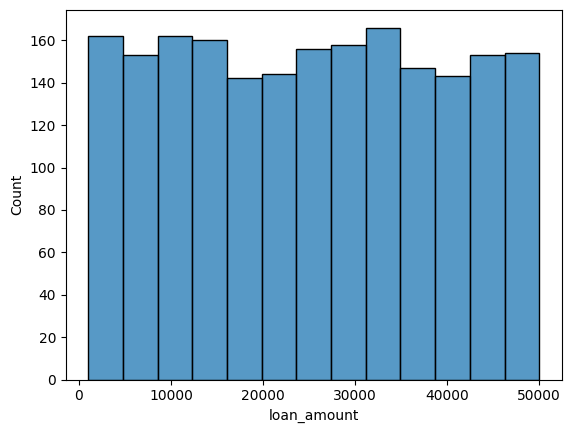

In [59]:
sns.histplot(df['loan_amount'])

Text(0.5, 1.0, 'Distribution of loan_amount (MEDV)')

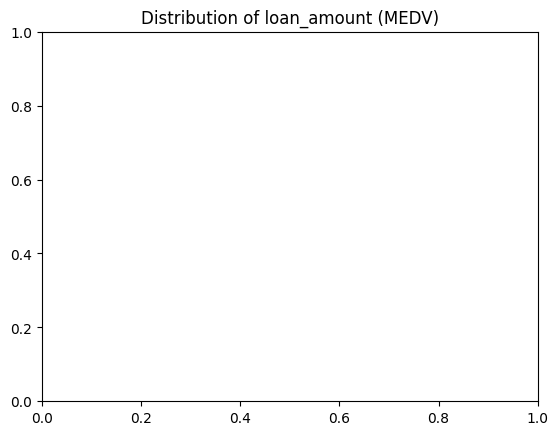

In [60]:
plt.title('Distribution of loan_amount (MEDV)')

In [ ]:
plt.xlabel('MEDV')

Text(0, 0.5, 'Frequency')

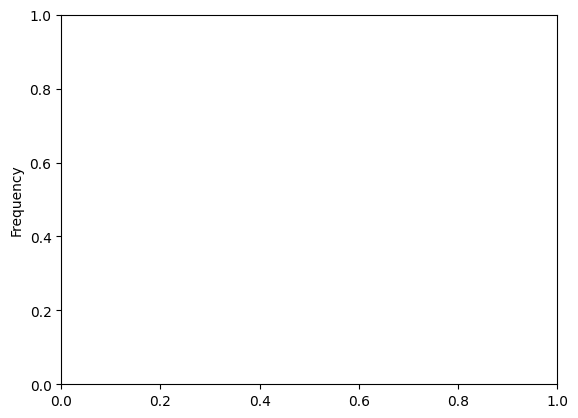

In [61]:
plt.ylabel('Frequency')

In [62]:
plt.show()

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns



In [39]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='years_employed', ylabel='loan_amount'>

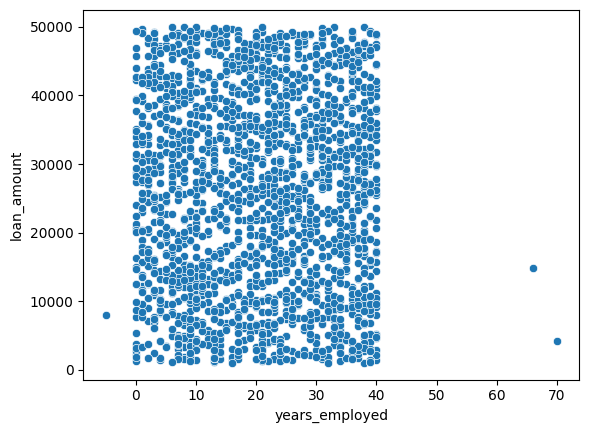

In [63]:
sns.scatterplot(x=df['years_employed'], y=df['loan_amount'])

Text(0.5, 1.0, 'Relationship between RM and MEDV')

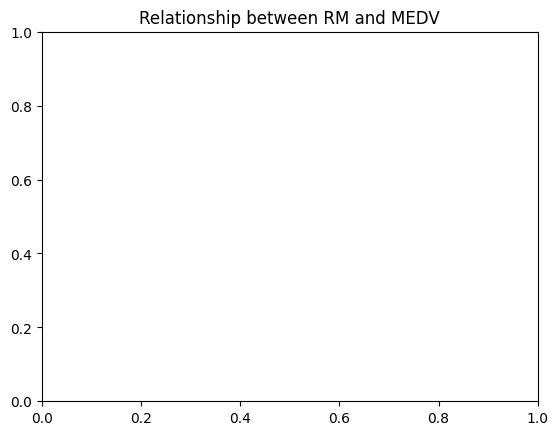

In [64]:
plt.title('Relationship between RM and MEDV')

Text(0.5, 0, 'Average Number of Rooms (RM)')

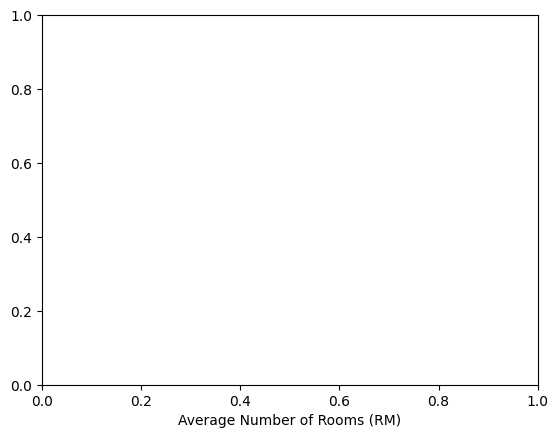

In [65]:
plt.xlabel('Average Number of Rooms (RM)')

Text(0, 0.5, 'House Price (MEDV)')

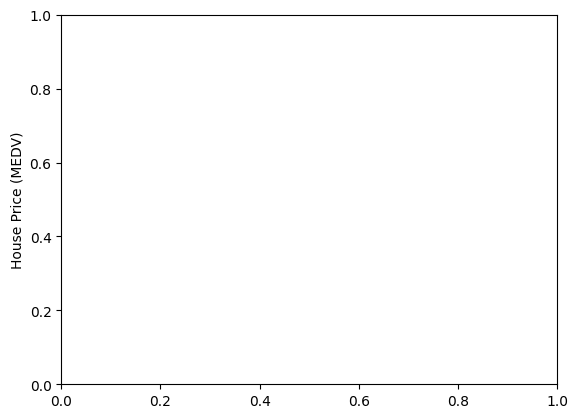

In [66]:
plt.ylabel('House Price (MEDV)')

In [67]:
plt.show()

Interpretation
Scatter plot shows how the target variable changes with Years of Employment.
If the points show an upward trend, there is a positive relationship.
This indicates that individuals with more years of employment tend to have higher target values.
If the points are widely scattered without a clear pattern, the relationship is weak.
Report Statement

"The scatter plot indicates a positive relationship between Years of Employment and the target variable. As employment experience increases, the target variable generally tends to increase, suggesting that Years of Employment may be an important predictor in the model."

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

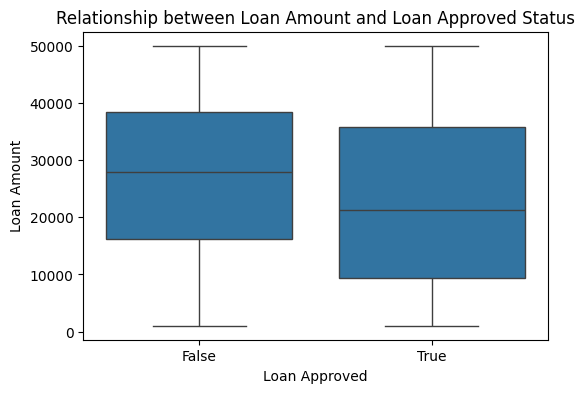

In [73]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_approved', y='loan_amount', data=df)
plt.title('Relationship between Loan Amount and Loan Approved Status')
plt.xlabel('Loan Approved')
plt.ylabel('Loan Amount')
plt.show()

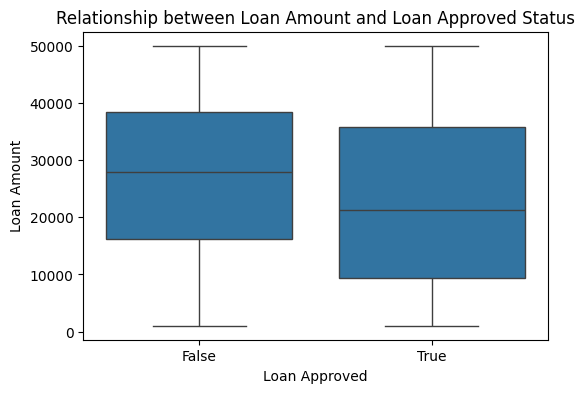

In [75]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_approved', y='loan_amount', data=df)
plt.title('Relationship between Loan Amount and Loan Approved Status')
plt.xlabel('Loan Approved')
plt.ylabel('Loan Amount')
plt.show()

In [78]:
##Q4. Outlier Detection and Treatment

# a) Detect outliers in numerical columns using the IQR method.
# b) Treat outliers using capping techniques.
##ans.
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]



In [79]:
 print(f"{col}: {len(outliers)} outliers")

points: 0 outliers


In [83]:
# Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
# columns.
##ans.
# Convert target variable to numerical format
# Example: loan_approved (True/False) → (1/0)

df['loan_approved'] = df['loan_approved'].astype(int)

# Drop unnecessary columns (modify according to your dataset)
df = df.drop(columns=['name'], errors='ignore')

# Display the first few rows
print(df.head())

               city  income  credit_score  loan_amount  years_employed  \
0         East Jill  113810           389        39698              27   
1     New Jamesside   44592           729        15446              28   
2      Lake Roberto   33278           584        11189              13   
3  West Melanieview  127196           344        48823              29   
4         Mariastad   66048           496        47174               4   

   points  loan_approved  
0      50              0  
1      55              0  
2      45              0  
3      50              0  
4      25              0  


In [85]:
##Q6. Feature Selection and Data Splitting

# a) Separate independent variables (X) and dependent variable (y)
# b) Split the dataset into training and testing sets.

#ans.
# Independent variables (features)
X = df.drop('loan_approved', axis=1)

# Dependent variable (target)
y = df['loan_approved']

# Display the shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Preview
print(X.head())
print(y.head())

Shape of X: (2000, 6)
Shape of y: (2000,)
               city  income  credit_score  loan_amount  years_employed  points
0         East Jill  113810           389        39698              27      50
1     New Jamesside   44592           729        15446              28      55
2      Lake Roberto   33278           584        11189              13      45
3  West Melanieview  127196           344        48823              29      50
4         Mariastad   66048           496        47174               4      25
0    0
1    0
2    0
3    0
4    0
Name: loan_approved, dtype: int64


In [87]:
# (b)
from sklearn.model_selection import train_test_split

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)


In [96]:
##Q9. Model Evaluation – Confusion Matrix

# a) Generate the confusion matrix.
# b) Interpret the results.
##ans.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [100]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

NameError: name 'y_pred' is not defined

In [101]:
## Re-applying Feature Scaling and One-Hot Encoding for consistency
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split

# IMPORTANT: Re-run train_test_split to ensure X_train and X_test are in their original state
# with the 'city' column present before one-hot encoding.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# One-hot encode the 'city' column, ensuring consistent columns across train and test sets.
# First, apply get_dummies to X_train
X_train_encoded = pd.get_dummies(X_train, columns=['city'], drop_first=True)

# Get the list of columns from the encoded X_train. This will be the reference for X_test.
train_cols = X_train_encoded.columns

# Apply get_dummies to X_test
X_test_encoded = pd.get_dummies(X_test, columns=['city'], drop_first=True)

# Reindex X_test_encoded to match the columns of X_train_encoded.
# Any columns present in X_train_encoded but not in X_test_encoded will be added with 0s.
# Any columns present in X_test_encoded but not in X_train_encoded will be dropped.
# This ensures both dataframes have the exact same feature set for scaling.
X_test_encoded = X_test_encoded.reindex(columns=train_cols, fill_value=0)

# Assign the consistently encoded data back to X_train and X_test
X_train = X_train_encoded
X_test = X_test_encoded

# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
# Now, X_train and X_test have identical columns, so scaling will work without error.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the shapes of the scaled data
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (1600, 1533)
Scaled X_test shape: (400, 1533)


In [105]:
## Q10. Model Evaluation – ROC Curve & AUC
# a) Plot the ROC curve.
# b) Calculate the AUC score

from sklearn.metrics import roc_auc_score

In [106]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Get probability predictions for the positive class (class 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.9796278109339981
